# Geração de Sinal Sintético Multivariado (5 canais → 1 alvo)

Este notebook gera um dataset sintético **multivariado** para validar a Learnable Wavelet Layer (LWT) em uma configuração mais realista:

- **5 canais** independentes, cada um produzido por uma instância separada do `SyntheticSignalGenerator` com sua própria seed.
- **Target univariado** definido como combinação linear ponderada dos canais limpos no fim da janela (pesos fixos `[0.4, 0.2, 0.15, 0.15, 0.1]`, normalizados para somar 1).
- **5.000 timesteps** brutos × `sequence_length=256` → ~4.744 janelas com `stride=1`, `horizon=1`.

Saídas em `data/`: `X_train/val/test.npy` no formato `(N, 256, 5)` e `y_train/val/test.npy` no formato `(N,)`.

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('.')
from src.data_generator import MultivariateSyntheticGenerator
from config.experiment_config import (
    SYNTHETIC_SIGNAL_CONFIG, MULTIVARIATE_CONFIG,
    DATA_DIR, SEED,
)

np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('SYNTHETIC_SIGNAL_CONFIG:'); [print(f'  {k}: {v}') for k,v in SYNTHETIC_SIGNAL_CONFIG.items()];
print('MULTIVARIATE_CONFIG:');     [print(f'  {k}: {v}') for k,v in MULTIVARIATE_CONFIG.items()];

SYNTHETIC_SIGNAL_CONFIG:
  n_samples: 5000
  sequence_length: 256
  trend_degree: 2
  n_harmonics: 5
  base_frequency: 0.01
  noise_level: 0.3
  spike_probability: 0.02
  spike_magnitude: 3.0
  regime_changes: 3
  random_seed: 42
MULTIVARIATE_CONFIG:
  n_channels: 5
  channel_seeds: [42, 43, 44, 45, 46]
  target_weights: [0.4, 0.2, 0.15, 0.15, 0.1]
  horizon: 1
  stride: 1


## 1. Gerar sinal multivariado

In [2]:
# Parâmetros do gerador de cada canal (excluímos chaves não suportadas pelo SyntheticSignalGenerator)
gen_kwargs = {k: v for k, v in SYNTHETIC_SIGNAL_CONFIG.items()
              if k not in ('n_samples', 'sequence_length', 'n_features', 'random_seed')}

generator = MultivariateSyntheticGenerator(
    n_samples=SYNTHETIC_SIGNAL_CONFIG['n_samples'],
    n_channels=MULTIVARIATE_CONFIG['n_channels'],
    channel_seeds=MULTIVARIATE_CONFIG['channel_seeds'],
    target_weights=MULTIVARIATE_CONFIG['target_weights'],
    **gen_kwargs,
)

noisy, clean = generator.generate()
print('noisy:', noisy.shape, 'clean:', clean.shape)
for meta in generator.metadata['per_channel']:
    print(f"  canal {meta['channel']} (seed={meta['seed']}): SNR={meta['snr_db']:.2f} dB, spikes={meta['n_spikes']}")

noisy: (5000, 5) clean: (5000, 5)
  canal 0 (seed=42): SNR=10.45 dB, spikes=105
  canal 1 (seed=43): SNR=10.52 dB, spikes=97
  canal 2 (seed=44): SNR=10.40 dB, spikes=96
  canal 3 (seed=45): SNR=10.36 dB, spikes=96
  canal 4 (seed=46): SNR=10.54 dB, spikes=98


## 2. Visualizar canais (clean vs noisy)

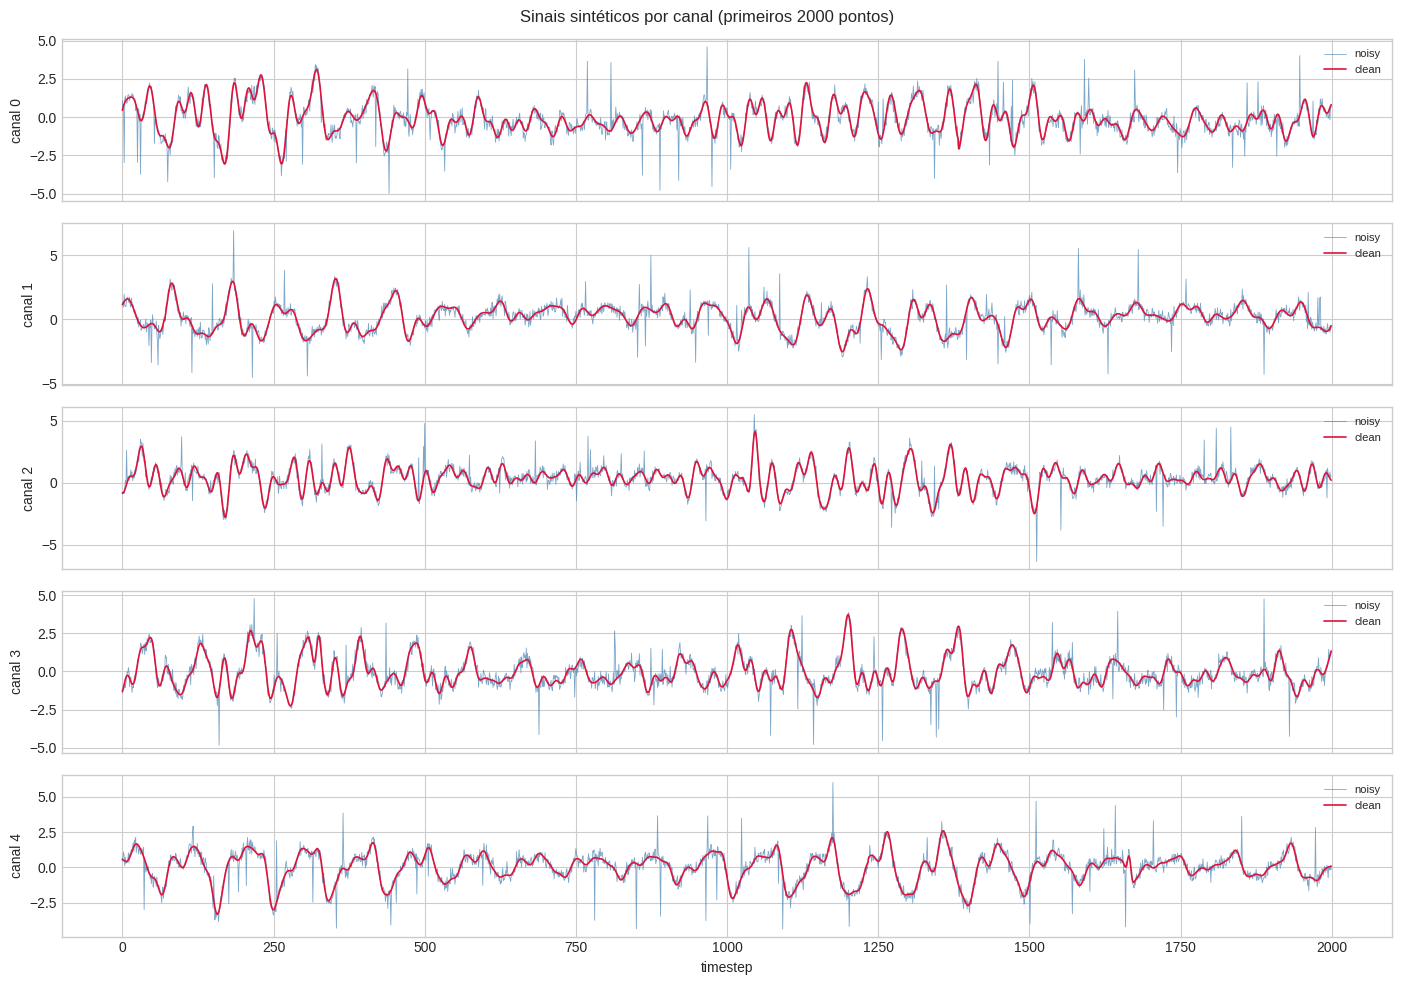

In [3]:
T = noisy.shape[0]
C = noisy.shape[1]
win_lo, win_hi = 0, min(2000, T)

fig, axes = plt.subplots(C, 1, figsize=(14, 2.0 * C), sharex=True)
for c in range(C):
    axes[c].plot(noisy[win_lo:win_hi, c], color='steelblue', lw=0.6, alpha=0.7, label='noisy')
    axes[c].plot(clean[win_lo:win_hi, c], color='crimson',   lw=1.2,             label='clean')
    axes[c].set_ylabel(f'canal {c}')
    axes[c].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('timestep')
plt.suptitle(f'Sinais sintéticos por canal (primeiros {win_hi-win_lo} pontos)', fontsize=12)
plt.tight_layout(); plt.show()

## 3. Correlação entre canais (clean)

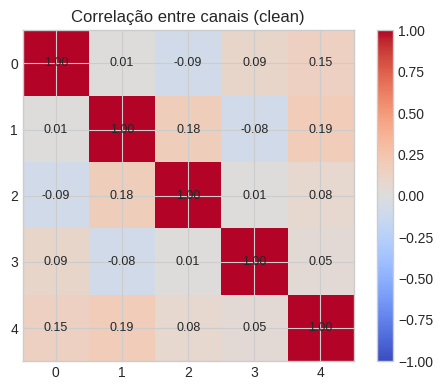

In [4]:
corr = np.corrcoef(clean.T)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
for i in range(C):
    for j in range(C):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_xticks(range(C)); ax.set_yticks(range(C))
ax.set_title('Correlação entre canais (clean)')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 4. Janelamento e target ponderado

In [5]:
X, y = generator.create_regression_dataset(
    sequence_length=SYNTHETIC_SIGNAL_CONFIG['sequence_length'],
    horizon=MULTIVARIATE_CONFIG['horizon'],
    stride=MULTIVARIATE_CONFIG['stride'],
)
print('X:', X.shape, X.dtype, '   y:', y.shape, y.dtype)
print('target weights (normalizados):', generator.target_weights.tolist())
print(f'y stats: mean={y.mean():.4f}, std={y.std():.4f}, min={y.min():.4f}, max={y.max():.4f}')

X: (4744, 256, 5) float32    y: (4744,) float32
target weights (normalizados): [0.3999999999995999, 0.19999999999979995, 0.14999999999984995, 0.14999999999984995, 0.09999999999989997]
y stats: mean=-0.0110, std=0.5159, min=-1.4784, max=2.4179


### 4.1 Distribuição do target

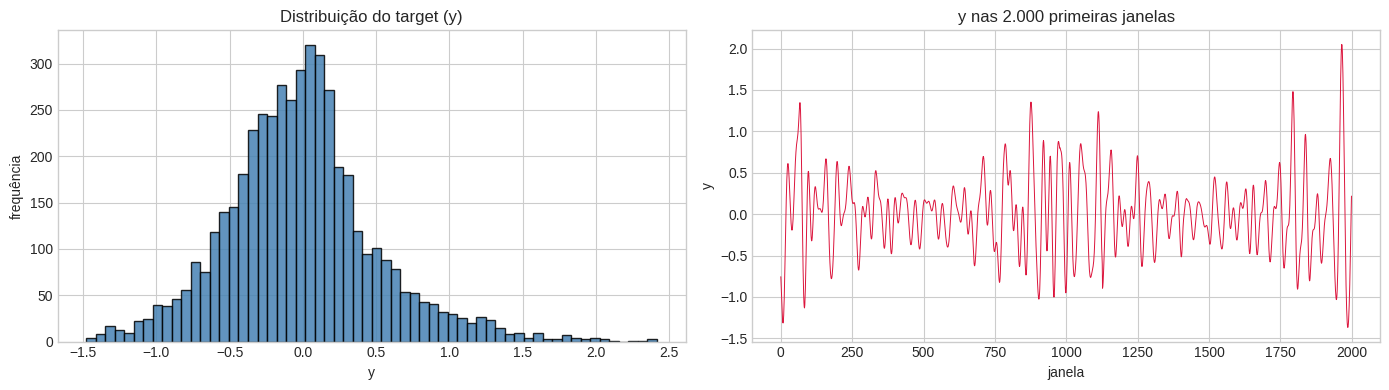

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=60, color='steelblue', edgecolor='k', alpha=0.85)
axes[0].set_title('Distribuição do target (y)')
axes[0].set_xlabel('y'); axes[0].set_ylabel('frequência')
axes[1].plot(y[:2000], color='crimson', lw=0.7)
axes[1].set_title('y nas 2.000 primeiras janelas')
axes[1].set_xlabel('janela'); axes[1].set_ylabel('y')
plt.tight_layout(); plt.show()

## 5. Split treino/val/teste (cronológico 70/15/15)

In [7]:
n = len(X)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X[:train_end],          y[:train_end]
X_val,   y_val   = X[train_end:val_end],   y[train_end:val_end]
X_test,  y_test  = X[val_end:],            y[val_end:]

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape,   y_val.shape)
print('Test: ', X_test.shape,  y_test.shape)
print(f'Total: {n} janelas ({len(X_train)/n:.1%} / {len(X_val)/n:.1%} / {len(X_test)/n:.1%})')

Train: (3320, 256, 5) (3320,)
Val:   (712, 256, 5) (712,)
Test:  (712, 256, 5) (712,)
Total: 4744 janelas (70.0% / 15.0% / 15.0%)


## 6. Salvar em `data/`

In [8]:
np.save(DATA_DIR / 'X_train.npy', X_train)
np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'X_val.npy',   X_val)
np.save(DATA_DIR / 'y_val.npy',   y_val)
np.save(DATA_DIR / 'X_test.npy',  X_test)
np.save(DATA_DIR / 'y_test.npy',  y_test)

metadata = {**generator.metadata,
            'split': {'train': len(X_train), 'val': len(X_val), 'test': len(X_test)}}
with open(DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

for p in sorted(DATA_DIR.glob('*')):
    sz = p.stat().st_size / (1024 * 1024)
    print(f'  {p.name:20s}  {sz:7.2f} MB')

  X_test.npy               3.48 MB
  X_train.npy             16.21 MB
  X_val.npy                3.48 MB
  metadata.json            0.00 MB
  y_test.npy               0.00 MB
  y_train.npy              0.01 MB
  y_val.npy                0.00 MB
